<a href="https://colab.research.google.com/github/Abhishekksoni/deep_learning/blob/main/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

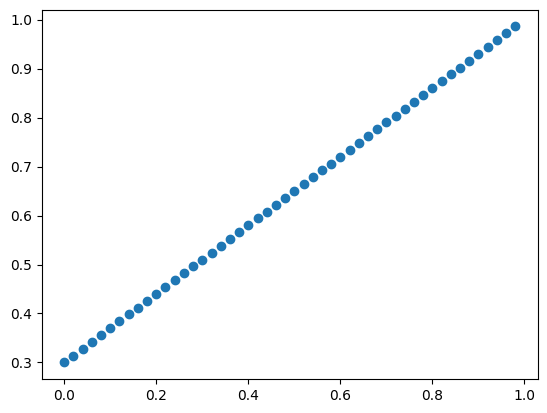

In [ ]:
plt.scatter(X[:, 0], Y[:, 0])
plt.show()

In [ ]:
len(X), len(Y)

(50, 50)

In [ ]:
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = Y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions = None):
  plt.figure(figsize = (10, 7))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  plt.scatter(test_data, test_labels, c="g", s=6, label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=5, label="Predections")


  plt.legend(prop={"size": 14})



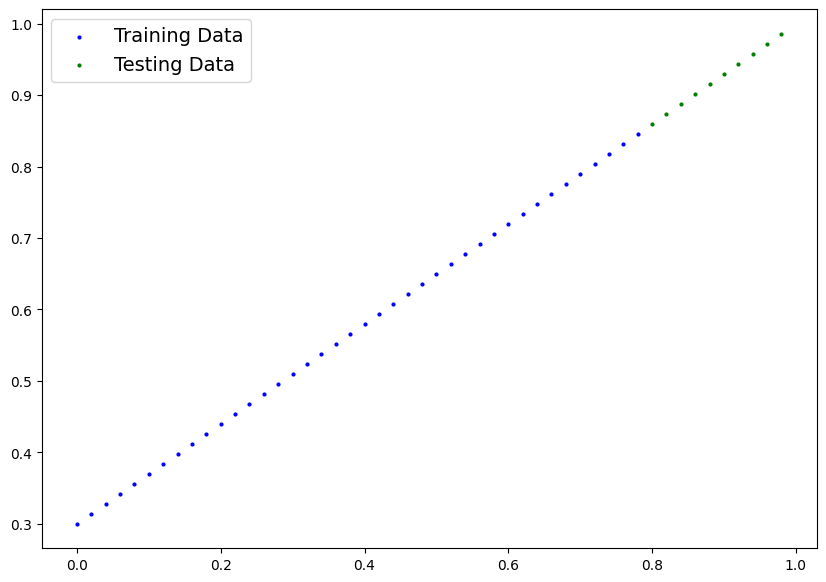

In [ ]:
plot_predictions()

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, dtype = float, requires_grad = True))
    self.bias = nn.Parameter(torch.randn(1, dtype = float, requires_grad = True))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias


In [ ]:
torch.manual_seed(42)
model_0 = LinearRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288], dtype=torch.float64))])

In [ ]:
with torch.inference_mode():
  Y_preds = model_0(X_test)

  # Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(Y_preds)}")
print(f"Predicted values:\n{Y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)


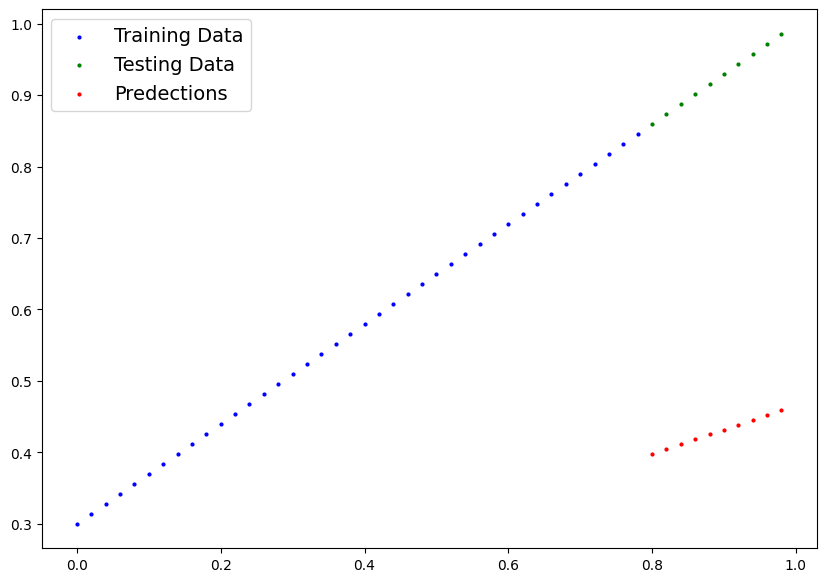

In [ ]:
plot_predictions(predictions=Y_preds)

In [ ]:
loss = Y_test - Y_preds

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_0.parameters(), lr= 0.01)

In [ ]:
torch.manual_seed(42)

epoch = 200

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epoch):

  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, Y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

  with torch.inference_mode():

    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, Y_test)


    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | Train Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Train Loss: 0.024110007347825514 | Test Loss: 0.05536158699724347
Epoch: 10 | Train Loss: 0.02067767559874483 | Test Loss: 0.04777608724738177
Epoch: 20 | Train Loss: 0.017245207684573466 | Test Loss: 0.039503687501352545
Epoch: 30 | Train Loss: 0.013806407854057762 | Test Loss: 0.031231287755323422
Epoch: 40 | Train Loss: 0.010375746041937575 | Test Loss: 0.023645788005461764
Epoch: 50 | Train Loss: 0.006941608190805723 | Test Loss: 0.015373388259432607
Epoch: 60 | Train Loss: 0.003502808360290019 | Test Loss: 0.00710098851340345
Epoch: 70 | Train Loss: 0.0025897632540065967 | Test Loss: 0.008446411294987088
Epoch: 80 | Train Loss: 0.0025897632540065967 | Test Loss: 0.008446411294987088
Epoch: 90 | Train Loss: 0.0025897632540065967 | Test Loss: 0.008446411294987088
Epoch: 100 | Train Loss: 0.0025897632540065967 | Test Loss: 0.008446411294987088
Epoch: 110 | Train Loss: 0.0025897632540065967 | Test Loss: 0.008446411294987088
Epoch: 120 | Train Loss: 0.0025897632540065967 | T

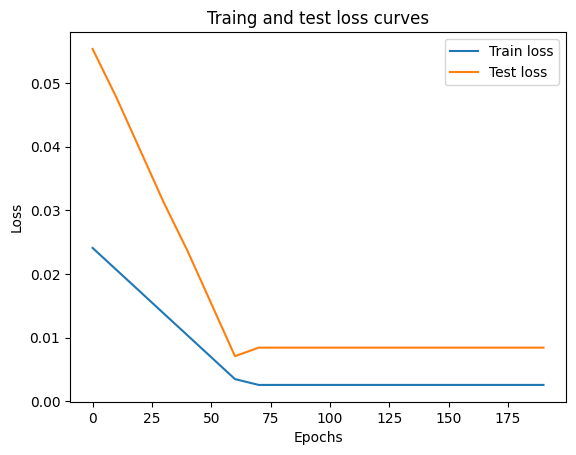

In [ ]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Traing and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6951], dtype=torch.float64)),
             ('bias', tensor([0.2993], dtype=torch.float64))])

In [ ]:
model_0.eval()

with torch.inference_mode():
  y_pred = model_0(X_test)

y_pred

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]], dtype=torch.float64)

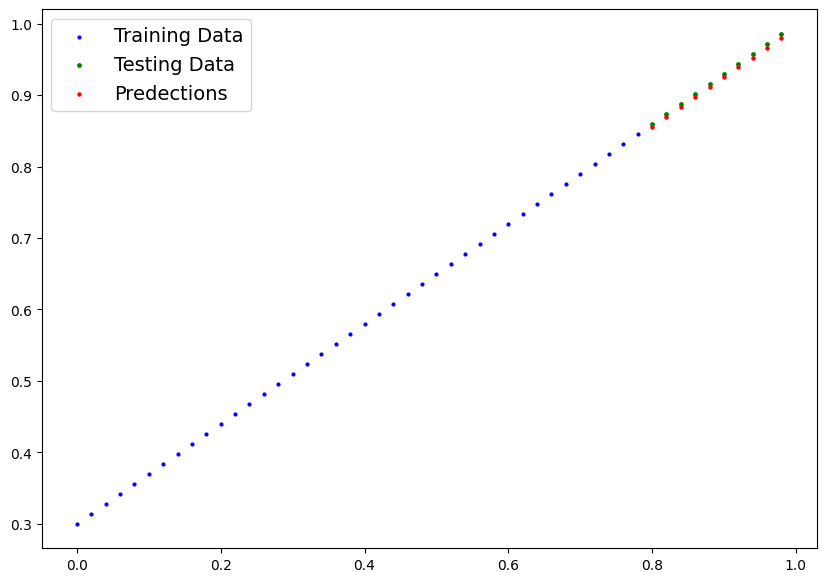

In [ ]:
plot_predictions(predictions=y_pred)

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 2117 Sep 11 11:16 models/01_pytorch_workflow_model_0.pth
